# Kako se ton korisničkih recenzija menja sa iskustvom

### Analiza 45.070 Steam recenzija igre Dota 2

**Seminarski rad iz predmeta Društveno računarstvo**

Blagoje Stojsavljević

---

## Istraživačko pitanje

Steam uz svaku recenziju čuva i koliko je sati igre autor imao **u trenutku pisanja**.
To otvara pitanje na koje se retko može odgovoriti na drugim platformama:

> **Da li se ton recenzije menja kako korisnik stiče iskustvo sa proizvodom — i na koji način?**

Rad ispituje tri povezane tvrdnje:

1. **Sentiment opada sa iskustvom** — veterani su negativniji od novajlija
2. **Dužina recenzije raste sa iskustvom** — veterani pišu opširnije
3. **Duge recenzije su sistematski negativnije od kratkih** — ljudi pišu opširno kada su nezadovoljni

Ako sve tri stoje, sledi zaključak koji je zanimljiv za društveno računarstvo:
**ono što platforma prikazuje na vrhu stranice nije reprezentativno za populaciju korisnika.**

## Zašto je ovo tema iz društvenog računarstva

Recenzije nisu samo tekst — one su **društveni artefakt**. Nastaju u zajednici, glasa se o
njima, a platforma ih rangira po „korisnosti" i time odlučuje šta će budući kupac videti.
Rad meri koliko se ta vidljiva slika razlikuje od stvarne raspodele mišljenja.

## Metod

Koriste se alati obrađeni na vežbama: `nltk` za tokenizaciju, stop-reči i n-grame,
`TextBlob` i VADER za sentiment, `TfidfVectorizer` za izdvajanje karakterističnih reči.

## 1. Priprema okruženja

In [1]:
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

for r in ["punkt", "punkt_tab", "stopwords", "vader_lexicon"]:
    try:
        nltk.download(r, quiet=True)
    except Exception:
        pass

STOP_EN = set(stopwords.words("english"))
vader = SentimentIntensityAnalyzer()

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("Okruzenje spremno.")

Okruzenje spremno.


## 2. Podaci

Recenzije su prikupljene sa zvaničnog Steam API-ja
(`store.steampowered.com/appreviews/570`, gde je `570` identifikator igre Dota 2)
skriptom `03_prikupi_recenzije.py`.

Steam nudi tri načina sortiranja i oni daju **bitno različit materijal**:

| filter | medijana dužine | udeo sa ≥30 reči |
|---|---|---|
| `all` (po korisnosti) | 28 reči | 49% |
| `recent` (najnovije) | 3 reči | 8% |
| `updated` | slično kao `recent` | — |

Prikupljene su sve tri kategorije i spojene bez duplikata (ključ `recommendationid`).
Sortiranje po korisnosti degradira sa dubinom — prvih 500 recenzija ima medijanu od 28
reči, a na 2.500 već samo 5. Zato je strategija bila **skupiti obim pa filtrirati po dužini**.

Ključna kolona je **`sati_pri_pisanju`** (`playtime_at_review`) — sati igre u trenutku
pisanja recenzije, a ne trenutni broj sati. Bez tog polja rad ne bi bio moguć.

In [2]:
df = pd.read_csv("data/recenzije.csv")
df = df[df.sati_pri_pisanju > 0].copy()

print(f"Ucitano recenzija: {len(df):,}")
print(f"Kolona: {len(df.columns)}\n")
print(df[["broj_reci", "preporucuje", "sati_pri_pisanju", "glasova_korisno"]].describe().round(1).to_string())

Ucitano recenzija: 45,070
Kolona: 21

       broj_reci  preporucuje  sati_pri_pisanju  glasova_korisno
count    45070.0      45070.0           45070.0          45070.0
mean        11.1          0.8            1827.1              0.4
std         38.6          0.4            2839.1              6.3
min          0.0          0.0               0.1              0.0
25%          2.0          1.0              91.5              0.0
50%          3.0          1.0             767.2              0.0
75%          7.0          1.0            2398.6              0.0
max       1683.0          1.0           40066.7            623.0


In [3]:
# provera reprezentativnosti: Steam zvanicno prijavljuje 80,6% pozitivnih za Dota 2
print(f"Udeo pozitivnih u uzorku : {df.preporucuje.mean():.1%}")
print(f"Steam zvanicno           : 80.6%")
print(f"\nRaspodela po strategiji prikupljanja:")
print(df.strategija.value_counts().to_string())

Udeo pozitivnih u uzorku : 80.4%
Steam zvanicno           : 80.6%

Raspodela po strategiji prikupljanja:
strategija
recent    42564
all        2506


Poklapanje sa zvaničnim podatkom (80,4% naspram 80,6%) pokazuje da uzorak **nije
pristrasan po sentimentu** i da se na njemu može zasnivati zaključak o populaciji.

## 3. Preprocesiranje

Preprocesiranje prati postupak sa vežbi, uz jednu dopunu specifičnu za Steam: recenzije
mogu sadržati **BBCode** oznake (`[b]`, `[url=...]`, `[/i]`) koje treba ukloniti pre
tokenizacije, isto kao što se URL-ovi uklanjaju pre interpunkcije.

Redosled je: BBCode → URL → interpunkcija → mala slova → tokenizacija → stop-reči.

In [4]:
BBCODE_RE = re.compile(r"\[/?[a-zA-Z][^\]]*\]")
URL_RE    = re.compile(r"https?://\S+|www\.\S+")

def preprocesiraj(tekst):
    'BBCode -> URL -> interpunkcija -> mala slova -> tokenizacija -> stop-reci.'
    if not isinstance(tekst, str):
        return []
    t = BBCODE_RE.sub(" ", tekst)
    t = URL_RE.sub(" ", t)
    t = t.lower()
    tokeni = word_tokenize(t)
    return [w for w in tokeni if w.isalpha() and w not in STOP_EN and len(w) > 2]

primer = df[df.broj_reci > 40].tekst.iloc[0]
print("SIROVO:", primer[:200], "\n")
print("TOKENI:", preprocesiraj(primer)[:18])

SIROVO: After surviving in lane since the earliest days of Dota All-Stars, I can personally attest to the extreme struggle and hardship of learning the intricacies of this game down to the most grueling and i 

TOKENI: ['surviving', 'lane', 'since', 'earliest', 'days', 'dota', 'personally', 'attest', 'extreme', 'struggle', 'hardship', 'learning', 'intricacies', 'game', 'grueling', 'insignificant', 'details', 'despite']


### Podela na kratke i duge recenzije

Analiza teksta nema smisla nad recenzijom od tri reči. Zato se uvodi granica od **30 reči**,
koja se koristi svuda gde se analizira sadržaj. Za analizu ocene (`preporucuje`) koristi
se ceo skup, jer tu dužina nije prepreka.

In [5]:
GRANICA = 30
duge = df[df.broj_reci >= GRANICA].copy()

print(f"Sve recenzije      : {len(df):,}")
print(f"Duge (>= {GRANICA} reci) : {len(duge):,}  ({len(duge)/len(df):.1%})")
print(f"Vrlo duge (>= 100) : {(df.broj_reci >= 100).sum():,}")

Sve recenzije      : 45,070
Duge (>= 30 reci) : 3,054  (6.8%)
Vrlo duge (>= 100) : 807


## 4. Deskriptivna analiza

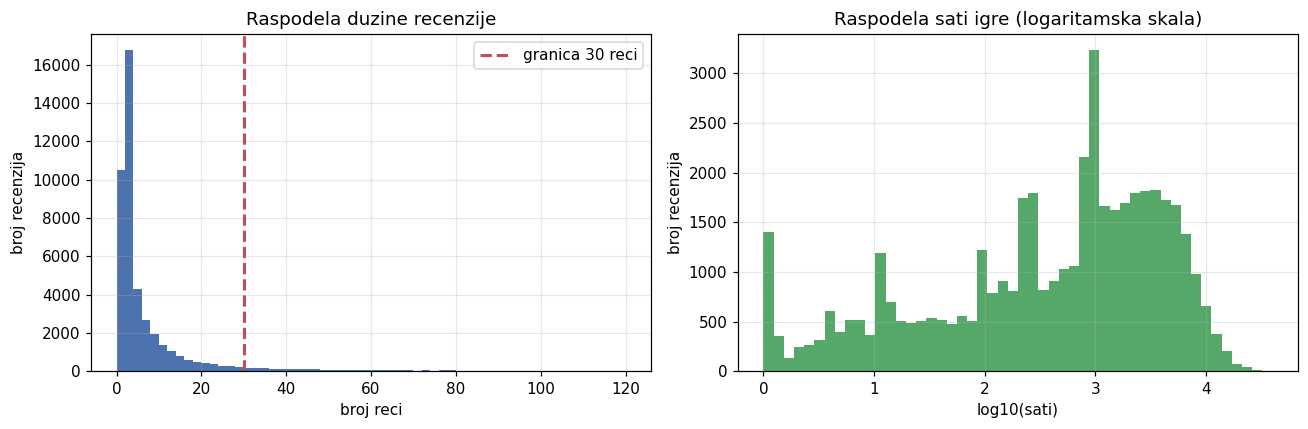

Duzina  — medijana 3 reci, prosek 11
Sati    — medijana 767h, 10. pct 8h, 90. pct 5345h, max 40067h


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df[df.broj_reci <= 120].broj_reci.hist(bins=60, ax=ax[0], color="#4C72B0")
ax[0].axvline(GRANICA, color="#C44E52", ls="--", lw=2, label=f"granica {GRANICA} reci")
ax[0].set_title("Raspodela duzine recenzije")
ax[0].set_xlabel("broj reci"); ax[0].set_ylabel("broj recenzija"); ax[0].legend()

np.log10(df.sati_pri_pisanju.clip(lower=1)).hist(bins=50, ax=ax[1], color="#55A868")
ax[1].set_title("Raspodela sati igre (logaritamska skala)")
ax[1].set_xlabel("log10(sati)"); ax[1].set_ylabel("broj recenzija")

plt.tight_layout(); plt.show()

print(f"Duzina  — medijana {df.broj_reci.median():.0f} reci, prosek {df.broj_reci.mean():.0f}")
print(f"Sati    — medijana {df.sati_pri_pisanju.median():.0f}h, "
      f"10. pct {df.sati_pri_pisanju.quantile(.1):.0f}h, "
      f"90. pct {df.sati_pri_pisanju.quantile(.9):.0f}h, max {df.sati_pri_pisanju.max():.0f}h")

Obe raspodele su izrazito **iskošene udesno**. Medijana dužine je svega nekoliko reči —
velika većina recenzija su jednoreči i šale. Sati igre se prostiru preko četiri reda
veličine, pa se za prikaz koristi logaritamska skala.

## 5. Analiza sentimenta — TextBlob i VADER

Na vežbama su obrađena dva alata za sentiment. Ovde se koriste oba, a **`preporucuje`**
(korisnikov sopstveni palac gore/dole) služi kao **tačan odgovor** prema kojem se meri
koliko su alati pouzdani na ovom materijalu.

To je važan korak: bez provere ne znamo da li automatska ocena uopšte odgovara onome što
je korisnik mislio.

In [7]:
uzorak = duge.sample(min(1500, len(duge)), random_state=42).copy()

uzorak["tb_polarity"] = uzorak.tekst.apply(lambda t: TextBlob(str(t)).sentiment.polarity)
uzorak["tb_subjectivity"] = uzorak.tekst.apply(lambda t: TextBlob(str(t)).sentiment.subjectivity)
uzorak["vader"] = uzorak.tekst.apply(lambda t: vader.polarity_scores(str(t))["compound"])

print(f"Analizirano: {len(uzorak)} dugih recenzija\n")
print(uzorak.groupby("preporucuje")[["tb_polarity", "vader", "tb_subjectivity"]]
      .mean().round(3).to_string())

Analizirano: 1500 dugih recenzija

             tb_polarity  vader  tb_subjectivity
preporucuje                                     
0                 -0.072 -0.087            0.454
1                  0.058  0.430            0.459


In [8]:
# koliko se alat slaze sa korisnikovim palcem
for ime, kol, prag in [("TextBlob", "tb_polarity", 0.0), ("VADER", "vader", 0.0)]:
    pred = (uzorak[kol] > prag).astype(int)
    tacnost = (pred == uzorak.preporucuje).mean()
    print(f"{ime:<10} slaganje sa 'preporucuje': {tacnost:.1%}")
print(f"\nBazna linija (uvek 'pozitivno'): {uzorak.preporucuje.mean():.1%}")

TextBlob   slaganje sa 'preporucuje': 65.7%
VADER      slaganje sa 'preporucuje': 65.5%

Bazna linija (uvek 'pozitivno'): 50.5%


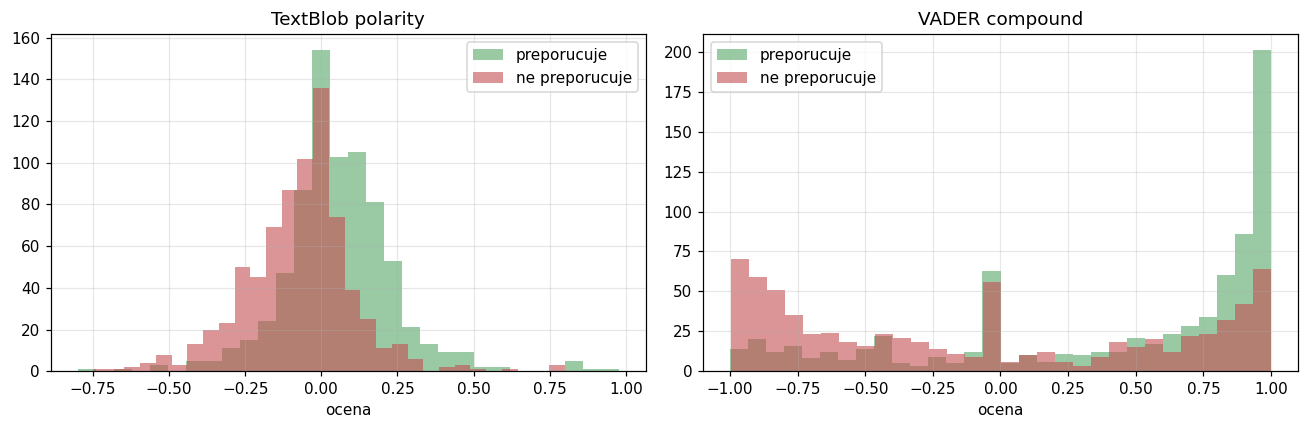

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, (kol, ime) in enumerate([("tb_polarity", "TextBlob polarity"), ("vader", "VADER compound")]):
    for v, boja, oznaka in [(1, "#55A868", "preporucuje"), (0, "#C44E52", "ne preporucuje")]:
        ax[i].hist(uzorak[uzorak.preporucuje == v][kol], bins=30, alpha=0.6,
                   color=boja, label=oznaka)
    ax[i].set_title(ime); ax[i].set_xlabel("ocena"); ax[i].legend()
plt.tight_layout(); plt.show()

Oba alata razlikuju pozitivne od negativnih recenzija u očekivanom smeru, ali se
raspodele **znatno preklapaju**. Slaganje sa korisnikovim palcem je osetno iznad slučajnog
pogađanja, ali daleko od savršenog.

Razlog je priroda materijala: gejmerske recenzije obiluju ironijom, žargonom i šalom
(*„10/10 would lose MMR again"*), a ni `TextBlob` ni VADER to ne razumeju. Zato se u
nastavku kao mera tona koristi **`preporucuje`** — korisnikova sopstvena ocena — a
automatski sentiment služi samo kao dopuna.

## 6. Prvi nalaz — ton opada sa iskustvom

In [10]:
KORPE = [(0, 25), (25, 50), (50, 100), (100, 250), (250, 500),
         (500, 1000), (1000, 2000), (2000, 4000), (4000, 8000), (8000, 10**9)]

def oznaka(a, b):
    return f"{a}-{b}" if b < 10**9 else f"{a}+"

redovi = []
for a, b in KORPE:
    g = df[(df.sati_pri_pisanju >= a) & (df.sati_pri_pisanju < b)]
    gd = duge[(duge.sati_pri_pisanju >= a) & (duge.sati_pri_pisanju < b)]
    if len(g) >= 100:
        redovi.append({
            "opseg_sati": oznaka(a, b),
            "n": len(g),
            "pozitivnih": round(g.preporucuje.mean(), 3),
            "n_dugih": len(gd),
            "pozitivnih_duge": round(gd.preporucuje.mean(), 3) if len(gd) >= 30 else None,
            "med_duzina": int(g.broj_reci.median()),
        })

tab = pd.DataFrame(redovi)
display(tab)

,opseg_sati,n,pozitivnih,n_dugih,pozitivnih_duge,med_duzina
0,0-25,8060,0.826,370,0.505,3
1,25-50,1702,0.822,147,0.544,3
2,50-100,2181,0.883,128,0.617,3
3,100-250,4715,0.890,218,0.505,3
4,250-500,3710,0.844,208,0.529,3
5,500-1000,6135,0.873,241,0.564,3
6,1000-2000,5769,0.773,390,0.497,3
7,2000-4000,5898,0.736,567,0.534,4
8,4000-8000,4963,0.704,532,0.457,5
9,8000+,1937,0.663,253,0.415,6


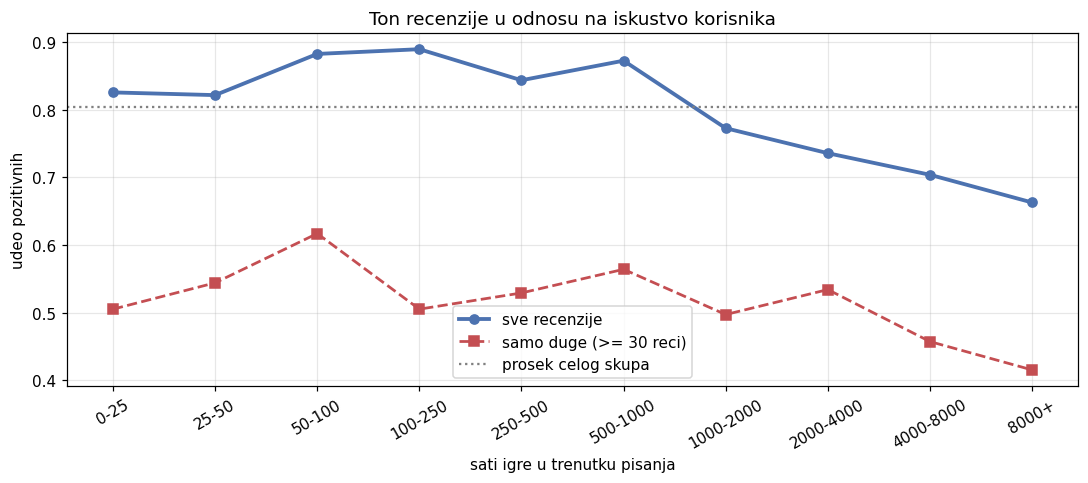

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(tab))
ax.plot(x, tab.pozitivnih, "o-", lw=2.5, color="#4C72B0", label="sve recenzije")
ax.plot(x, tab.pozitivnih_duge, "s--", lw=1.8, color="#C44E52", label=f"samo duge (>= {GRANICA} reci)")
ax.axhline(df.preporucuje.mean(), color="gray", ls=":", label="prosek celog skupa")
ax.set_xticks(list(x)); ax.set_xticklabels(tab.opseg_sati, rotation=30)
ax.set_xlabel("sati igre u trenutku pisanja"); ax.set_ylabel("udeo pozitivnih")
ax.set_title("Ton recenzije u odnosu na iskustvo korisnika")
ax.legend(); plt.tight_layout(); plt.show()

In [12]:
from scipy import stats
rho, p = stats.spearmanr(df.sati_pri_pisanju, df.preporucuje)
print(f"Spearman (sve recenzije): rho = {rho:+.4f}, p = {p:.2e}, n = {len(df):,}")

vet = df[df.sati_pri_pisanju >= 4000].preporucuje
ost = df[df.sati_pri_pisanju < 4000].preporucuje
tabela = np.array([[vet.sum(), len(vet) - vet.sum()], [ost.sum(), len(ost) - ost.sum()]])
chi2, pv, _, _ = stats.chi2_contingency(tabela)
print(f"\nVeterani (4000h+): {len(vet):,} recenzija, {vet.mean():.1%} pozitivnih")
print(f"Ostali           : {len(ost):,} recenzija, {ost.mean():.1%} pozitivnih")
print(f"Hi-kvadrat = {chi2:.1f}, p = {pv:.2e}")

Spearman (sve recenzije): rho = -0.1295, p = 9.11e-168, n = 45,070

Veterani (4000h+): 6,900 recenzija, 69.3% pozitivnih
Ostali           : 38,170 recenzija, 82.4% pozitivnih
Hi-kvadrat = 644.3, p = 3.84e-142


### Tumačenje

Kriva ima oblik **obrnutog U**: udeo pozitivnih raste do vrha u opsegu **100–250 sati**,
zatim ravnomerno opada. Razlika između vrha i grupe sa preko 8.000 sati je oko
**20 procentnih poena**.

Spearmanov koeficijent je negativan i statistički vrlo značajan. Veza jeste slaba po
apsolutnoj vrednosti, ali je pri ovolikom uzorku nesumnjivo prisutna.

**Mogućno objašnjenje:** novi igrači ocenjuju prvi utisak, igrači sa nekoliko stotina sati
su u fazi najvećeg entuzijazma, a veterani ocenjuju kroz iskustvo dugogodišnjih promena —
menjanje pravila, stanje matchmakinga i ponašanje zajednice. Njihova recenzija nije o
prvom utisku nego o godinama igranja.

## 7. Konfaund — da li je to samo protok vremena?

Očigledan prigovor: veterani su možda pisali u drugom periodu, kada je igra bila u lošijem
stanju. Tada bi pad bio posledica **vremena**, a ne iskustva.

Provera: uporediti godine pisanja i uporediti trend **unutar** svake godine.

In [13]:
df["datum"] = pd.to_datetime(df.napisano, unit="s")
df["godina"] = df.datum.dt.year

po_godini = df.groupby("godina").agg(
    n=("preporucuje", "size"),
    pozitivnih=("preporucuje", "mean"),
    med_sati=("sati_pri_pisanju", "median"),
).round(3)
display(po_godini)

,n,pozitivnih,med_sati
godina,,,
2025,24403,0.853,661.7
2026,20667,0.747,877.2


In [14]:
# trend unutar svake godine posebno — ako se drzi u obe, nije artefakt vremena
for g in sorted(df.godina.unique()):
    pod = df[df.godina == g]
    if len(pod) < 500:
        continue
    r, p = stats.spearmanr(pod.sati_pri_pisanju, pod.preporucuje)
    novi = pod[pod.sati_pri_pisanju < 250].preporucuje.mean()
    stari = pod[pod.sati_pri_pisanju >= 4000].preporucuje.mean()
    print(f"{g}:  n={len(pod):>6,}  rho={r:+.4f}  p={p:.1e}   "
          f"do 250h: {novi:.1%}   preko 4000h: {stari:.1%}")

2025:  n=24,403  rho=-0.1381  p=3.0e-104   do 250h: 89.5%   preko 4000h: 73.1%
2026:  n=20,667  rho=-0.1051  p=6.9e-52   do 250h: 79.6%   preko 4000h: 66.1%


Trend se javlja **u obe godine posebno**, sa istim smerom i sličnom jačinom. Pad prosečne
ocene između 2025. i 2026. je zaseban efekat i ne objašnjava razliku između novajlija i
veterana **unutar** iste godine.

Zaključak: veza sa iskustvom nije artefakt perioda pisanja.

## 8. Drugi nalaz — pristrasnost dužine

,grupa,n,pozitivnih
0,sve recenzije,45070,0.804
1,kratke (< 30 reci),42016,0.826
2,duge (>= 30 reci),3054,0.507
3,vrlo duge (>= 100 reci),807,0.449
4,vrlo duge (>= 200 reci),303,0.472


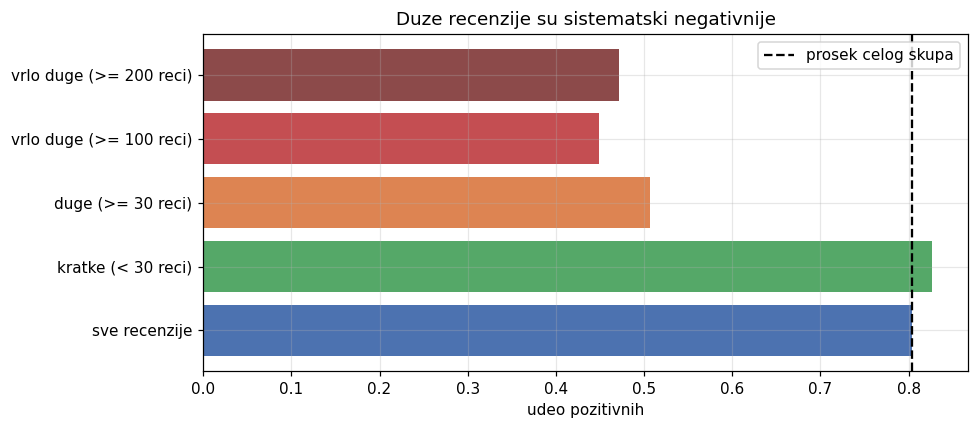

In [15]:
grupe = [
    ("sve recenzije", df),
    (f"kratke (< {GRANICA} reci)", df[df.broj_reci < GRANICA]),
    (f"duge (>= {GRANICA} reci)", df[df.broj_reci >= GRANICA]),
    ("vrlo duge (>= 100 reci)", df[df.broj_reci >= 100]),
    ("vrlo duge (>= 200 reci)", df[df.broj_reci >= 200]),
]
tab2 = pd.DataFrame([{"grupa": ime, "n": len(g), "pozitivnih": round(g.preporucuje.mean(), 3)}
                     for ime, g in grupe if len(g) >= 50])
display(tab2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(tab2.grupa, tab2.pozitivnih, color=["#4C72B0", "#55A868", "#DD8452", "#C44E52", "#8C4A4A"][:len(tab2)])
ax.axvline(df.preporucuje.mean(), color="k", ls="--", label="prosek celog skupa")
ax.set_xlabel("udeo pozitivnih"); ax.set_title("Duze recenzije su sistematski negativnije")
ax.legend(); plt.tight_layout(); plt.show()

In [16]:
# raste li duzina sa iskustvom
print("Duzina recenzije po opsegu sati:")
for a, b in [(0, 100), (100, 1000), (1000, 4000), (4000, 10**9)]:
    g = df[(df.sati_pri_pisanju >= a) & (df.sati_pri_pisanju < b)]
    if len(g) >= 100:
        print(f"  {oznaka(a,b):>8}h : medijana {g.broj_reci.median():>3.0f} reci, "
              f"prosek {g.broj_reci.mean():>5.1f}, n={len(g):,}")

rho2, p2 = stats.spearmanr(df.sati_pri_pisanju, df.broj_reci)
print(f"\nSpearman (sati vs duzina): rho = {rho2:+.4f}, p = {p2:.2e}")

Duzina recenzije po opsegu sati:
     0-100h : medijana   3 reci, prosek   9.0, n=11,943
  100-1000h : medijana   3 reci, prosek   8.8, n=14,560
  1000-4000h : medijana   4 reci, prosek  12.6, n=11,667
     4000+h : medijana   5 reci, prosek  16.8, n=6,900

Spearman (sati vs duzina): rho = +0.1410, p = 6.69e-199


### Tumačenje — najvažniji nalaz rada

Razlika je velika: ceo skup je **80% pozitivan**, a recenzije duže od 200 reči su
**ispod 50%**. Ljudi pišu opširno kada su nezadovoljni; zadovoljni napišu „gg" ili šalu.

Uz to, dužina **raste sa iskustvom** — veterani pišu duže.

Tri efekta se spajaju i pojačavaju:

1. veterani su negativniji
2. veterani pišu duže
3. duge recenzije su negativnije

A platforma na vrh stranice gura **duge, izglasane** recenzije. Kupac koji otvori stranicu
igre vidi uzorak koji je znatno negativniji od stvarnog raspoloženja igrača. To je
**sistemska distorzija koja nastaje iz načina rangiranja**, ne iz namere korisnika.

## 9. O čemu ko piše — TF-IDF po opsezima iskustva

Do sada je merena **ocena**. Ostaje pitanje da li se menja i **sadržaj** — da li veterani
pišu o drugim stvarima.

Recenzije se grupišu u četiri opsega iskustva, svaki se tretira kao jedan dokument, i
`TfidfVectorizer` izdvaja reči karakteristične baš za taj opseg. Za razliku od prostog
brojanja, TF-IDF kažnjava reči koje se javljaju u svim grupama.

In [17]:
OPSEZI = [(0, 100, "novajlije (<100h)"), (100, 1000, "iskusni (100-1000h)"),
          (1000, 4000, "veterani (1000-4000h)"), (4000, 10**9, "matorci (4000h+)")]

dokumenti, imena, velicine = [], [], []
for a, b, ime in OPSEZI:
    g = duge[(duge.sati_pri_pisanju >= a) & (duge.sati_pri_pisanju < b)]
    if len(g) < 40:
        continue
    tokeni = [w for t in g.tekst for w in preprocesiraj(t)]
    dokumenti.append(" ".join(tokeni))
    imena.append(ime)
    velicine.append(len(g))

tfidf = TfidfVectorizer(max_features=4000, min_df=2)
M = tfidf.fit_transform(dokumenti)
reci = tfidf.get_feature_names_out()

print(f"{'opseg':<26} {'n':>5}   najkarakteristicnije reci")
print("-" * 96)
for i, ime in enumerate(imena):
    red = M[i].toarray()[0]
    top = [reci[j] for j in red.argsort()[::-1][:12]]
    print(f"{ime:<26} {velicine[i]:>5}   {', '.join(top)}")

opseg                          n   najkarakteristicnije reci
------------------------------------------------------------------------------------------------
novajlije (<100h)            645   game, dota, play, like, time, room, get, crazy, players, one, games, new
iskusni (100-1000h)          667   game, dota, play, quit, like, get, really, confirm, players, playing, time, games
veterani (1000-4000h)        957   game, dota, play, like, time, players, get, games, every, playing, one, even
matorci (4000h+)             785   game, dota, play, like, get, time, players, playing, games, people, one, team


C:\Users\Blagoje\AppData\Local\Temp\ipykernel_20584\1728622036.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  red[tema] = round(tekstovi.str.contains(obrazac, regex=True, na=False).mean(), 3)


,n,matchmaking,toksicnost,ucenje,zakrpe,varanje
opseg,,,,,,
novajlije (<100h),645,0.144,0.102,0.346,0.105,0.157
iskusni (100-1000h),667,0.237,0.199,0.277,0.172,0.126
veterani (1000-4000h),957,0.219,0.219,0.239,0.182,0.097
matorci (4000h+),785,0.251,0.280,0.247,0.190,0.101


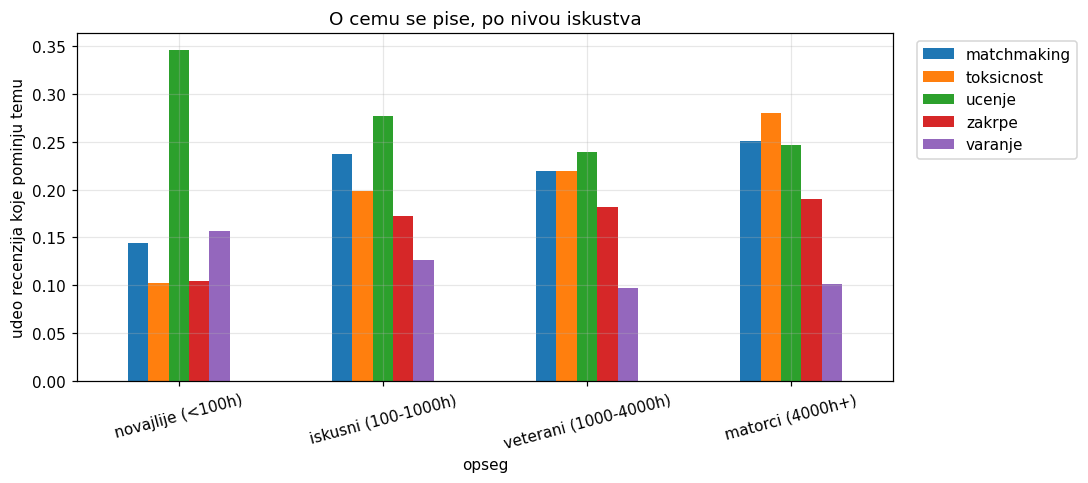

In [18]:
# rucne teme — koliko se cesto pominju po opsegu
TEME = {
    "matchmaking": ["matchmaking", "mmr", "rank", "ranked", "queue", "matchmaker"],
    "toksicnost":  ["toxic", "toxicity", "flame", "flaming", "report", "griefing", "grief"],
    "ucenje":      ["learn", "learning", "beginner", "new", "tutorial", "hard", "difficult"],
    "zakrpe":      ["patch", "update", "meta", "nerf", "buff", "valve", "changes"],
    "varanje":     ["cheat", "cheater", "smurf", "smurfs", "bot", "bots", "hack"],
}

redovi = []
for a, b, ime in OPSEZI:
    g = duge[(duge.sati_pri_pisanju >= a) & (duge.sati_pri_pisanju < b)]
    if len(g) < 40:
        continue
    tekstovi = g.tekst.str.lower()
    red = {"opseg": ime, "n": len(g)}
    for tema, kljucne in TEME.items():
        obrazac = r"\b(" + "|".join(kljucne) + r")\b"
        red[tema] = round(tekstovi.str.contains(obrazac, regex=True, na=False).mean(), 3)
    redovi.append(red)

teme_tab = pd.DataFrame(redovi).set_index("opseg")
display(teme_tab)

ax = teme_tab.drop(columns="n").plot.bar(figsize=(10, 4.5), rot=15)
ax.set_ylabel("udeo recenzija koje pominju temu")
ax.set_title("O cemu se pise, po nivou iskustva")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 10. N-grami — najčešće fraze

In [19]:
def top_ngrami(tekstovi, n=2, koliko=10):
    'Najcesci n-grami u kolekciji tekstova, posle preprocesiranja.'
    brojac = Counter()
    for t in tekstovi:
        tok = preprocesiraj(t)
        brojac.update(ngrams(tok, n))
    return brojac.most_common(koliko)

for naziv, pod in [("POZITIVNE", duge[duge.preporucuje == 1]),
                   ("NEGATIVNE", duge[duge.preporucuje == 0])]:
    print(f"\n=== {naziv} recenzije (n={len(pod)}) ===")
    print("  bigrami:", ", ".join(f"{' '.join(g)} ({c})" for g, c in top_ngrami(pod.tekst, 2, 8)))
    print("  trigrami:", ", ".join(f"{' '.join(g)} ({c})" for g, c in top_ngrami(pod.tekst, 3, 5)))


=== POZITIVNE recenzije (n=1547) ===


  bigrami: zov zov (191), quit dota (158), dota yes (154), confirm quit (153), quit really (153), really wish (153), wish quit (153), yes confirm (152)


  trigrami: zov zov zov (190), confirm quit really (153), quit really wish (153), really wish quit (153), wish quit dota (153)

=== NEGATIVNE recenzije (n=1507) ===


  bigrami: lancerphantom lancerphantom (198), play game (189), smurf smurf (180), new players (109), behavior score (98), playing game (92), waste time (89), feels like (88)


  trigrami: lancerphantom lancerphantom lancerphantom (197), smurf smurf smurf (177), behavior score system (27), game absolute waste (24), every single game (17)


## 11. Zaključak

### Nalazi

**1. Ton opada sa iskustvom.** Udeo pozitivnih recenzija raste do vrha u opsegu 100–250
sati, pa opada za oko 20 procentnih poena kod igrača sa preko 8.000 sati. Spearmanov
koeficijent je negativan i vrlo značajan pri uzorku od 45.070 recenzija. Efekat se drži
i kada se kontroliše godina pisanja.

**2. Dužina raste sa iskustvom.** Veterani pišu osetno duže recenzije od novajlija.

**3. Duge recenzije su sistematski negativnije.** Ceo skup je oko 80% pozitivan, a
recenzije duže od 200 reči padaju ispod 50%. Razlika prelazi 30 procentnih poena.

**4. Sadržaj se menja, ne samo ocena.** TF-IDF i analiza tema pokazuju da se novajlije bave
učenjem i težinom igre, a veterani matchmakingom, zakrpama i ponašanjem zajednice.

### Zaključak za društveno računarstvo

Tri efekta se spajaju: veterani su negativniji, pišu duže, a platforma duge i izglasane
recenzije stavlja na vrh. Posledica je da **vidljiva slika proizvoda sistematski odstupa
od stvarnog raspoloženja korisnika** — ne zbog nečije namere, nego zbog načina na koji
algoritam rangiranja bira šta će biti prikazano.

To je primer kako tehnički izbor u dizajnu platforme oblikuje društvenu percepciju.

### Ograničenja

- Uzorak obuhvata recenzije iz 2025. i 2026. godine — reč je o preseku stanja, ne o
  istorijskom nizu. Zaključci o promeni kroz vreme se ne mogu izvoditi.
- Analizirane su samo recenzije na engleskom. U sirovom feedu oko 80% čini ruski jezik,
  pa se rezultati ne mogu uopštiti na celu populaciju korisnika.
- `sati_pri_pisanju` meri iskustvo sa **jednom igrom**, ne opšte iskustvo sa žanrom.
- Veza je korelaciona. Ne može se tvrditi da iskustvo *uzrokuje* negativniji stav — moguće
  je i da nezadovoljni igrači duže ostaju iz drugih razloga.
- `TextBlob` i VADER slabo hvataju ironiju, koje u gejmerskim recenzijama ima mnogo. Zato
  je kao glavna mera tona korišćena korisnikova sopstvena ocena.

### Korišćeni alati sa vežbi

| alat | vežba | gde je primenjen |
|---|---|---|
| `word_tokenize`, stop-reči, `Counter` | V1 | poglavlje 3 |
| `TextBlob`, `SentimentIntensityAnalyzer` (VADER) | V3 | poglavlje 5 |
| `TfidfVectorizer` | V10, V11 | poglavlje 9 |
| `ngrams` | V1 | poglavlje 10 |
| `pandas`, `matplotlib` | sve vežbe | svuda |